# Week 4 & 5: Multi-Model Training, Benchmarking & Serialization
## Cardiovascular Disease Classification Project

This notebook covers the complete training, evaluation, and serialization (`.pkl` export) of **7 machine learning classification algorithms**:

| Algorithm | Category | Serialized File | Assigned Week | Target Role |
| :--- | :--- | :--- | :--- | :--- |
| **Random Forest (Tuned)** | Ensemble Tree | `random_forest_model.pkl` | **Week 5** | 🏆 **Best Model (Primary)** |
| **Decision Tree Classifier** | Tree Classifier | `decision_tree_model.pkl` | **Week 4** | Baseline Non-Linear |
| **Logistic Regression** | Linear Model | `logistic_regression_model.pkl` | **Week 4** | Parametric Baseline |
| **AdaBoost Classifier** | Boosting Ensemble | `adaboost_model.pkl` | **Week 5** | Adaptive Boosting |
| **SVM (RBF Kernel)** | Support Vector Machine | `svm_model.pkl` | **Week 5** | Kernel Non-Linear |
| **K-Nearest Neighbors (KNN)** | Distance-Based | `knn_model.pkl` | **Week 5** | Instance-Based |
| **Gaussian Naive Bayes** | Probabilistic | `naive_bayes_model.pkl` | **Week 5** | Bayes Theorem Baseline |

### 1. Import Required Libraries

In [1]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded successfully!")

Libraries loaded successfully!


### 2. Load Processed Dataset & Feature Engineering

In [2]:
# Load cleaned unscaled dataset
data_path = os.path.join('..', 'dataset', 'processed', 'cardio_cleaned.csv')
df = pd.read_csv(data_path)

# Feature Engineering: Derived clinical pressure metrics
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['map_pressure'] = (((2 * df['ap_lo']) + df['ap_hi']) / 3.0).round(2)

feature_cols = [
    'age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
    'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi',
    'pulse_pressure', 'map_pressure'
]

X = df[feature_cols]
y = df['cardio']

print(f"Total Samples: {X.shape[0]:,}")
print(f"Feature Count: {X.shape[1]}")
print(f"Target Distribution:\n{y.value_counts(normalize=True).round(4) * 100}%")

Total Samples: 68,554
Feature Count: 14
Target Distribution:
cardio
0    50.54
1    49.46
Name: proportion, dtype: float64%


### 3. Stratified Train-Test Split & Standardization (`scaler.pkl`)

In [3]:
# 80% Train, 20% Test with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit Scaler on Training data only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create models export directory
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

# Save fitted StandardScaler artifact
scaler_file = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_file)
print(f"[OK] Saved Scaler artifact: {scaler_file}")

[OK] Saved Scaler artifact: ..\models\scaler.pkl


### 4. Define All 7 Classification Models

In [4]:
model_definitions = {
    "random_forest": {
        "name": "Random Forest",
        "category": "Ensemble Tree",
        "file": "random_forest_model.pkl",
        "week": "Week 5",
        "icon": "trees",
        "model": RandomForestClassifier(
            n_estimators=150, max_depth=14, min_samples_split=10, 
            min_samples_leaf=4, random_state=42, n_jobs=-1
        )
    },
    "logistic_regression": {
        "name": "Logistic Regression",
        "category": "Linear Model",
        "file": "logistic_regression_model.pkl",
        "week": "Week 4",
        "icon": "activity",
        "model": LogisticRegression(max_iter=1000, random_state=42)
    },
    "decision_tree": {
        "name": "Decision Tree Classifier",
        "category": "Tree Classifier",
        "file": "decision_tree_model.pkl",
        "week": "Week 4",
        "icon": "git-branch",
        "model": DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, random_state=42)
    },
    "adaboost": {
        "name": "AdaBoost",
        "category": "Boosting Ensemble",
        "file": "adaboost_model.pkl",
        "week": "Week 5",
        "icon": "zap",
        "model": AdaBoostClassifier(n_estimators=100, random_state=42)
    },
    "knn": {
        "name": "K-Nearest Neighbors",
        "category": "Distance Classifier",
        "file": "knn_model.pkl",
        "week": "Week 5",
        "icon": "users",
        "model": KNeighborsClassifier(n_neighbors=25, n_jobs=-1)
    },
    "naive_bayes": {
        "name": "Naive Bayes",
        "category": "Probabilistic",
        "file": "naive_bayes_model.pkl",
        "week": "Week 5",
        "icon": "sigma",
        "model": GaussianNB()
    },
    "svm": {
        "name": "SVM (RBF Kernel)",
        "category": "Support Vector Machine",
        "file": "svm_model.pkl",
        "week": "Week 5",
        "icon": "disc",
        "model": SVC(C=1.0, kernel="rbf", probability=True, max_iter=2500, random_state=42)
    }
}

print(f"Defined {len(model_definitions)} models for training.")

Defined 7 models for training.


### 5. Train All Models, Evaluate on Test Set & Save `.pkl` Artifacts

In [5]:
results_list = []
models_registry = {}
roc_data = {}

print("=" * 75)
print(f"{'Model Name':<28} | {'Accuracy':<9} | {'Precision':<9} | {'Recall':<9} | {'ROC-AUC':<9}")
print("=" * 75)

for key, config in model_definitions.items():
    name = config["name"]
    filename = config["file"]
    clf = config["model"]

    # 1. Fit on Scaled Training Data
    clf.fit(X_train_scaled, y_train)

    # 2. Predict on Test Set
    y_pred = clf.predict(X_test_scaled)
    
    # Predict Probabilities for ROC-AUC
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_scaled)

    # 3. Calculate Clinical Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Store ROC curve points
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)

    # Print row
    print(f"{name:<28} | {acc*100:6.2f}%   | {prec*100:6.2f}%   | {rec*100:6.2f}%   | {auc:7.4f}")

    # 4. Save Model Artifact (.pkl)
    pkl_path = os.path.join(models_dir, filename)
    joblib.dump(clf, pkl_path)

    # Record summary
    results_list.append({
        "Model": name,
        "Category": config["category"],
        "Week": config["week"],
        "File": filename,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "ROC-AUC": round(auc, 4)
    })

    models_registry[key] = {
        "key": key,
        "name": name,
        "category": config["category"],
        "file": filename,
        "week": config["week"],
        "icon": config["icon"],
        "accuracy": round(float(acc) * 100, 2),
        "precision": round(float(prec) * 100, 2),
        "recall": round(float(rec) * 100, 2),
        "f1_score": round(float(f1) * 100, 2),
        "roc_auc": round(float(auc), 4),
        "is_best": key == "random_forest"
    }

print("=" * 75)

# Also save best model as default trained_model.pkl
joblib.dump(model_definitions["random_forest"]["model"], os.path.join(models_dir, "trained_model.pkl"))

# Save Models Registry JSON for API and Frontend
registry_path = os.path.join(models_dir, "models_registry.json")
with open(registry_path, "w") as f:
    json.dump({
        "features": feature_cols,
        "best_model_key": "random_forest",
        "models": models_registry
    }, f, indent=4)

print(f"\n[SUCCESS] All 7 .pkl models saved to: {models_dir}")
print(f"[SUCCESS] Registry catalog saved to: {registry_path}")

Model Name                   | Accuracy  | Precision | Recall    | ROC-AUC  


Random Forest                |  73.37%   |  75.63%   |  68.10%   |  0.8002


Logistic Regression          |  72.74%   |  75.61%   |  66.26%   |  0.7914


Decision Tree Classifier     |  72.29%   |  74.95%   |  66.05%   |  0.7864


AdaBoost                     |  72.82%   |  76.77%   |  64.58%   |  0.7947


K-Nearest Neighbors          |  72.61%   |  74.74%   |  67.38%   |  0.7884
Naive Bayes                  |  72.04%   |  77.29%   |  61.54%   |  0.7844


SVM (RBF Kernel)             |  56.16%   |  57.16%   |  45.32%   |  0.5874

[SUCCESS] All 7 .pkl models saved to: ..\models
[SUCCESS] Registry catalog saved to: ..\models\models_registry.json


### 6. Benchmark Comparison Table

In [6]:
df_results = pd.DataFrame(results_list).sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)
df_results

,Model,Category,Week,File,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC
0,Random Forest,Ensemble Tree,Week 5,random_forest_model.pkl,73.37,75.63,68.10,71.67,0.8002
1,AdaBoost,Boosting Ensemble,Week 5,adaboost_model.pkl,72.82,76.77,64.58,70.15,0.7947
2,Logistic Regression,Linear Model,Week 4,logistic_regression_model.pkl,72.74,75.61,66.26,70.63,0.7914
3,K-Nearest Neighbors,Distance Classifier,Week 5,knn_model.pkl,72.61,74.74,67.38,70.87,0.7884
4,Decision Tree Classifier,Tree Classifier,Week 4,decision_tree_model.pkl,72.29,74.95,66.05,70.22,0.7864
5,Naive Bayes,Probabilistic,Week 5,naive_bayes_model.pkl,72.04,77.29,61.54,68.52,0.7844
6,SVM (RBF Kernel),Support Vector Machine,Week 5,svm_model.pkl,56.16,57.16,45.32,50.56,0.5874


### 7. ROC Curves Multi-Model Visualization

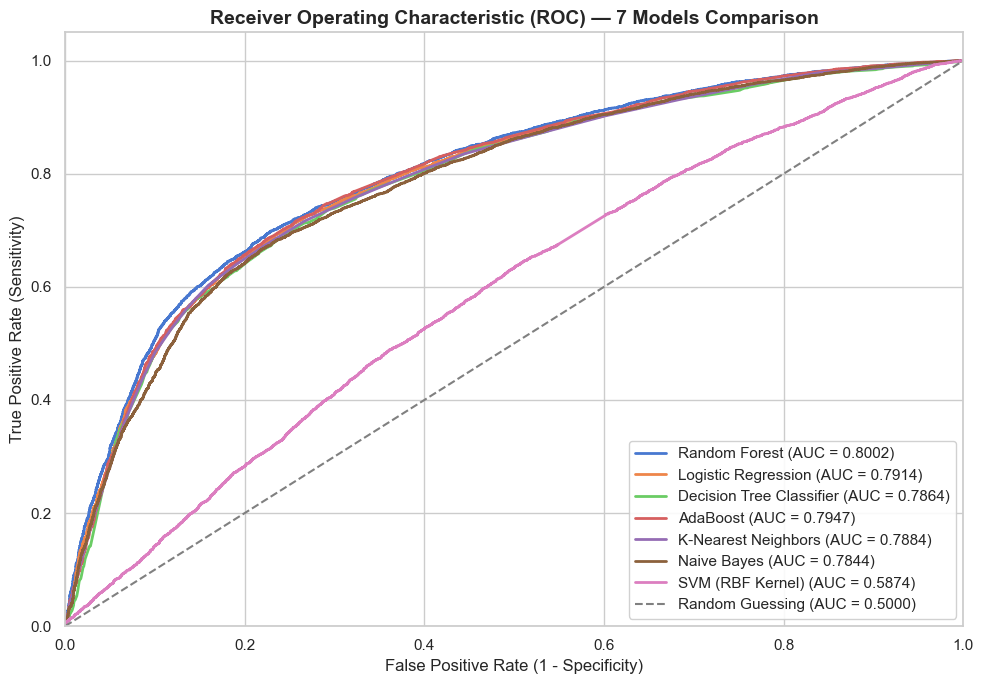

In [7]:
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) — 7 Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

### 8. End-to-End Live Inference Verification (Simultaneous 7-Model Prediction)

In [8]:
# Test sample patient profile
sample_patient = {
    'age_years': 55,
    'gender': 2,       # Male
    'height': 170,
    'weight': 82.0,
    'ap_hi': 145,
    'ap_lo': 90,
    'cholesterol': 2,  # Above Normal
    'gluc': 1,
    'smoke': 1,        # Smoker
    'alco': 0,
    'active': 1
}

# Feature computation
sample_patient['bmi'] = round(sample_patient['weight'] / ((sample_patient['height'] / 100) ** 2), 1)
sample_patient['pulse_pressure'] = sample_patient['ap_hi'] - sample_patient['ap_lo']
sample_patient['map_pressure'] = round(((2 * sample_patient['ap_lo']) + sample_patient['ap_hi']) / 3.0, 2)

df_sample = pd.DataFrame([sample_patient])[feature_cols]
scaled_sample = scaler.transform(df_sample)

print("=" * 65)
print("LIVE MULTI-MODEL PREDICTION TEST ON SAMPLE PATIENT:")
print(f"Age: {sample_patient['age_years']} | BP: {sample_patient['ap_hi']}/{sample_patient['ap_lo']} mmHg | BMI: {sample_patient['bmi']}")
print("=" * 65)

for key, config in model_definitions.items():
    model_obj = joblib.load(os.path.join(models_dir, config['file']))
    pred = int(model_obj.predict(scaled_sample)[0])
    if hasattr(model_obj, 'predict_proba'):
        prob = float(model_obj.predict_proba(scaled_sample)[0][1])
    else:
        decision = float(model_obj.decision_function(scaled_sample)[0])
        prob = 1.0 / (1.0 + np.exp(-decision))
    
    status = "🔴 Disease Detected" if pred == 1 else "🟢 Healthy"
    print(f"{config['name']:<25} -> {status:<20} (Risk: {prob*100:5.2f}%)")
print("=" * 65)

LIVE MULTI-MODEL PREDICTION TEST ON SAMPLE PATIENT:
Age: 55 | BP: 145/90 mmHg | BMI: 28.4


Random Forest             -> 🔴 Disease Detected   (Risk: 81.85%)
Logistic Regression       -> 🔴 Disease Detected   (Risk: 81.59%)
Decision Tree Classifier  -> 🔴 Disease Detected   (Risk: 86.69%)
AdaBoost                  -> 🔴 Disease Detected   (Risk: 66.36%)
K-Nearest Neighbors       -> 🔴 Disease Detected   (Risk: 96.00%)
Naive Bayes               -> 🔴 Disease Detected   (Risk: 98.39%)
SVM (RBF Kernel)          -> 🟢 Healthy            (Risk: 54.26%)
